FIRST 5 ROWS
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   NaN 

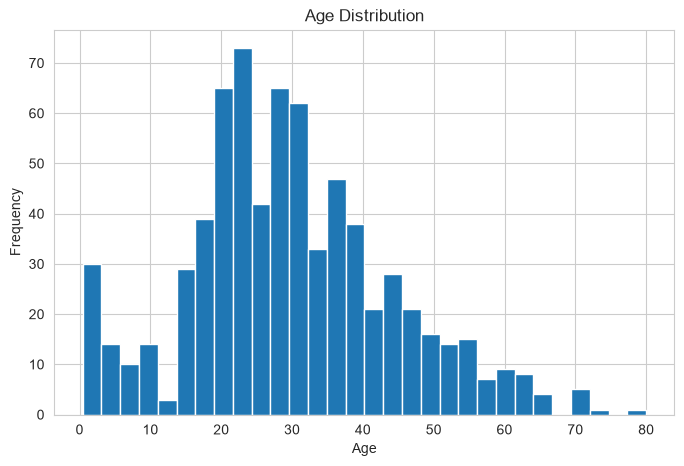

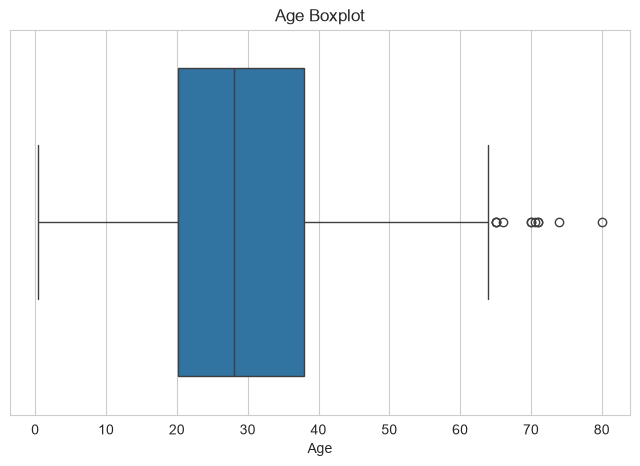

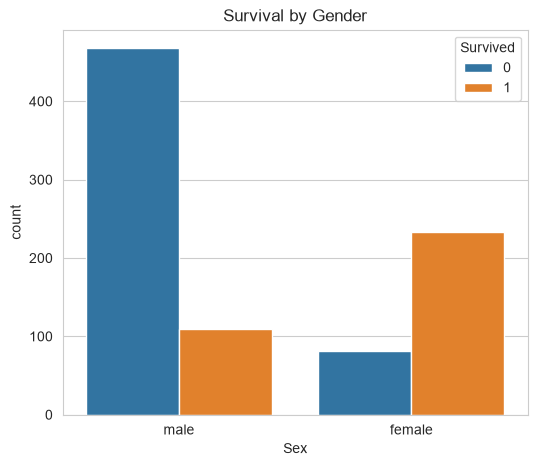

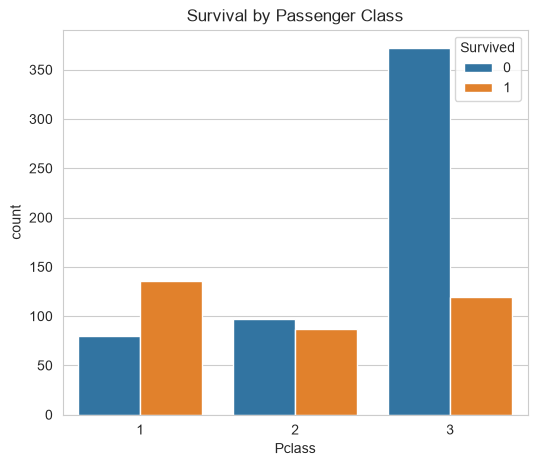

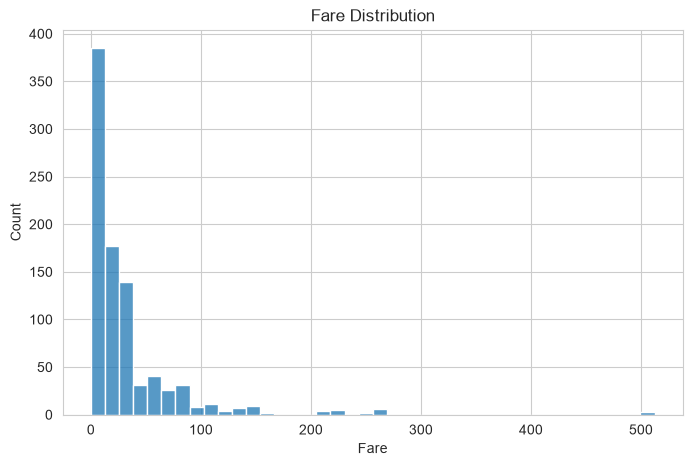

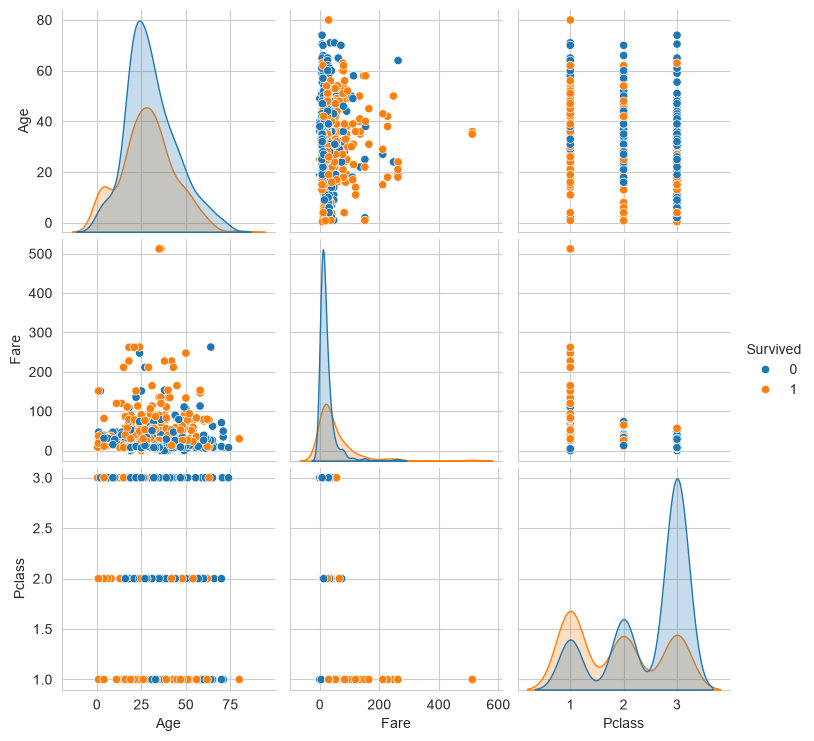

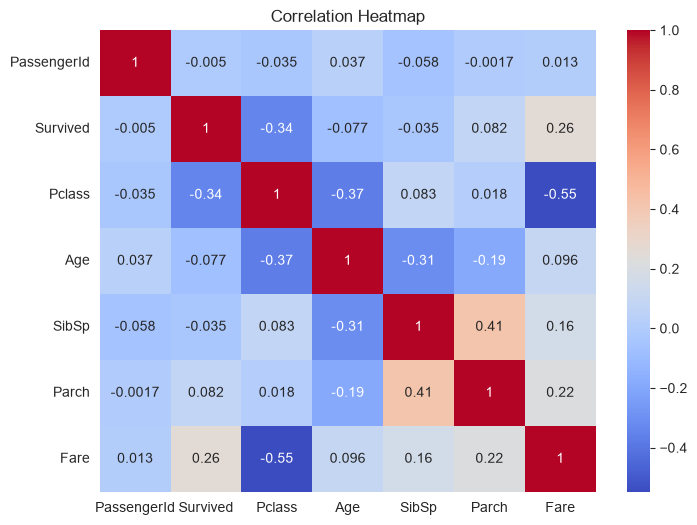

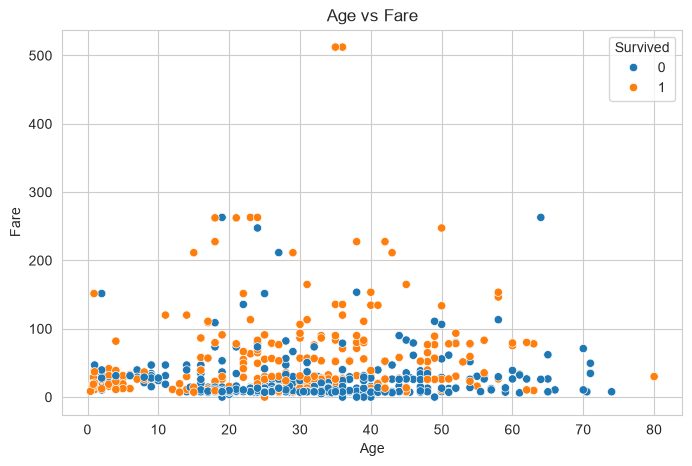



EDA COMPLETED SUCCESSFULLY
Graphs have been saved in the 'graphs' folder.


In [24]:
# ===============================
# Task 5 - Exploratory Data Analysis
# ===============================

import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Plot style
sns.set_style("whitegrid")

# Create graphs folder
os.makedirs("graphs", exist_ok=True)

# Load dataset
df = pd.read_csv("Titanic-Dataset.csv")

# -------------------------------
# Basic Information
# -------------------------------

print("="*60)
print("FIRST 5 ROWS")
print("="*60)
print(df.head())

print("\n")
print("="*60)
print("DATASET INFORMATION")
print("="*60)
df.info()

print("\n")
print("="*60)
print("STATISTICAL SUMMARY")
print("="*60)
print(df.describe())

print("\n")
print("="*60)
print("MISSING VALUES")
print("="*60)
print(df.isnull().sum())

print("\n")
print("="*60)
print("SURVIVAL COUNT")
print("="*60)
print(df["Survived"].value_counts())

print("\n")
print("="*60)
print("PASSENGER CLASS COUNT")
print("="*60)
print(df["Pclass"].value_counts())

print("\n")
print("="*60)
print("GENDER COUNT")
print("="*60)
print(df["Sex"].value_counts())

# =====================================
# 1. Age Distribution
# =====================================

plt.figure(figsize=(8,5))
plt.hist(df["Age"].dropna(), bins=30)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.savefig("graphs/01_Age_Distribution.png", dpi=300, bbox_inches="tight")
plt.show()

# =====================================
# 2. Age Boxplot
# =====================================

plt.figure(figsize=(8,5))
sns.boxplot(x=df["Age"])
plt.title("Age Boxplot")
plt.savefig("graphs/02_Age_Boxplot.png", dpi=300, bbox_inches="tight")
plt.show()

# =====================================
# 3. Survival by Gender
# =====================================

plt.figure(figsize=(6,5))
sns.countplot(x="Sex", hue="Survived", data=df)
plt.title("Survival by Gender")
plt.savefig("graphs/03_Survival_by_Gender.png", dpi=300, bbox_inches="tight")
plt.show()

# =====================================
# 4. Survival by Passenger Class
# =====================================

plt.figure(figsize=(6,5))
sns.countplot(x="Pclass", hue="Survived", data=df)
plt.title("Survival by Passenger Class")
plt.savefig("graphs/04_Survival_by_Class.png", dpi=300, bbox_inches="tight")
plt.show()

# =====================================
# 5. Fare Distribution
# =====================================

plt.figure(figsize=(8,5))
sns.histplot(df["Fare"], bins=40)
plt.title("Fare Distribution")
plt.xlabel("Fare")
plt.ylabel("Count")
plt.savefig("graphs/05_Fare_Distribution.png", dpi=300, bbox_inches="tight")
plt.show()

# =====================================
# 6. Pairplot
# =====================================

pair = sns.pairplot(
    df[["Age","Fare","Pclass","Survived"]].dropna(),
    hue="Survived"
)
pair.savefig("graphs/06_Pairplot.png", dpi=300)

# =====================================
# 7. Correlation Heatmap
# =====================================

plt.figure(figsize=(8,6))
numeric_df = df.select_dtypes(include=["number"])
sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.savefig("graphs/07_Correlation_Heatmap.png", dpi=300, bbox_inches="tight")
plt.show()

# =====================================
# 8. Scatter Plot
# =====================================

plt.figure(figsize=(8,5))
sns.scatterplot(x="Age", y="Fare", hue="Survived", data=df)
plt.title("Age vs Fare")
plt.savefig("graphs/08_Age_vs_Fare.png", dpi=300, bbox_inches="tight")
plt.show()

print("\n")
print("="*60)
print("EDA COMPLETED SUCCESSFULLY")
print("="*60)
print("Graphs have been saved in the 'graphs' folder.")

# Final Observations

## Missing Values
- The Age column contains missing values.
- The Cabin column has the highest number of missing values.
- The Embarked column has only a few missing values.

## Age Distribution
- Most passengers were between 20 and 40 years old.

## Survival Analysis
- Female passengers had a higher survival rate than male passengers.
- First-class passengers survived more frequently than second- and third-class passengers.

## Fare Analysis
- Most passengers paid lower fares.
- A few passengers paid very high fares.

## Correlation
- Passenger class and fare show a noticeable relationship with survival.

## Conclusion
Exploratory Data Analysis revealed that gender, passenger class, and fare significantly influenced survival. Missing values in Age and Cabin should be handled before building a machine learning model.